In [1]:
import sys
import numpy as np
import anndata as ad
import polars as pl

import src as scit
import matplotlib.pyplot as plt
import cv2

/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [36]:

acetearly = pl.read_csv('private/newest/goterm/acet_label_vs_rest_early.csv')

acetlate = pl.read_csv('private/newest/goterm/acet_label_vs_rest_late.csv')

methearly = pl.read_csv('private/newest/goterm/meth_label_vs_rest_early.csv')

methlate = pl.read_csv('private/newest/goterm/meth_label_vs_rest_late.csv')


In [45]:
ANATOMIC_TERM = False

if not ANATOMIC_TERM:
    ref = scit.ld.gtf('../data/dmel-all-r6.56.gtf', extra_key='gene_id')
    obodag = scit.ld.obodag('../data/go-basic.obo')
    ns2assoc = scit.ld.gaf('../data/fb.gaf', obodag, name_column=2)
else:
    ref = scit.ld.gtf('../data/dmel-all-r6.56.gtf', extra_key='gene_id')
    # stage 5 = early
    # stage 6 = late
    obodag = scit.ld.obodag('../data/dm-stage6.obo', namespaces = { 'insitu': 'MF' })
    ns2assoc = scit.ld.gaf('../data/stage6_gene2go.gaf', obodag, name_column=2)

../data/go-basic.obo: fmt(1.2) rel(2024-10-27) 44,017 Terms



Load BP Ontology Enrichment Analysis ...
Propagating term counts up: is_a
 82% 10,249 of 12,518 population items found in association

Load CC Ontology Enrichment Analysis ...
Propagating term counts up: is_a
 82% 10,249 of 12,518 population items found in association

Load MF Ontology Enrichment Analysis ...
Propagating term counts up: is_a
 82% 10,249 of 12,518 population items found in association

Runing BP Ontology Analysis: current study set of 200 IDs.
 83%    166 of    200 study items found in association
100%    200 of    200 study items found in population(12518)
Calculating 6,952 uncorrected p-values using fisher_scipy_stats
   6,952 terms are associated with  9,278 of 12,518 population items
   1,399 terms are associated with    146 of    200 study items
  METHOD fdr_bh:
       0 GO terms found significant (< 0.1=alpha) (  0 enriched +   0 purified): statsmodels fdr_bh
       0 study items associated with significant GO IDs (enriched)
       0 study items associated with s

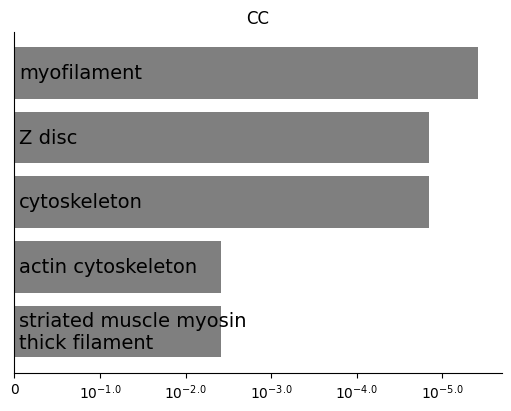

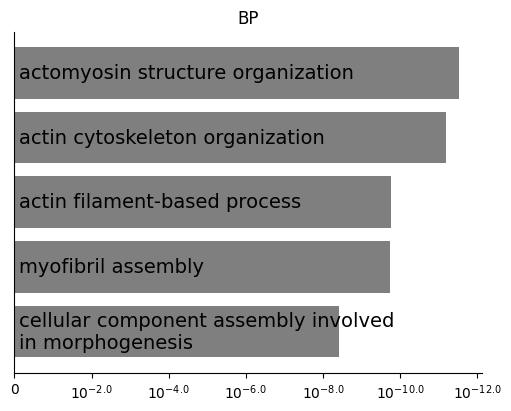

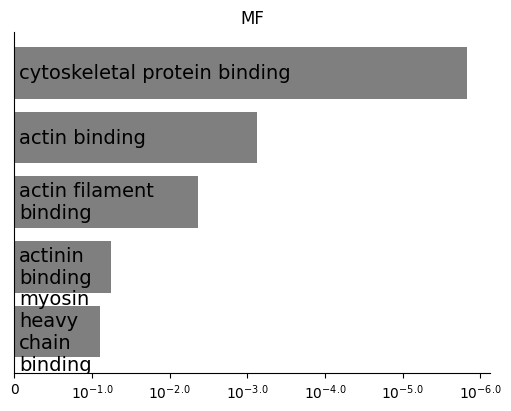

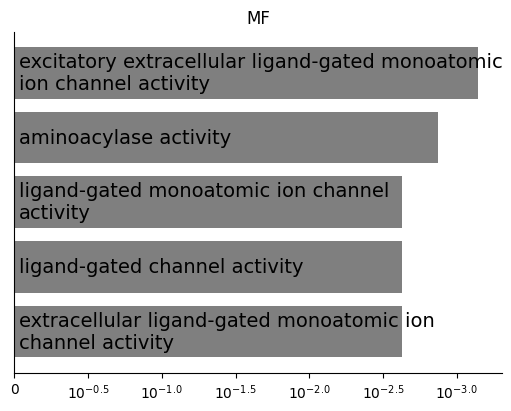

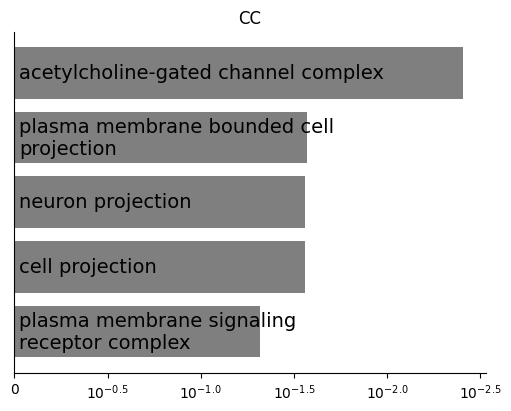

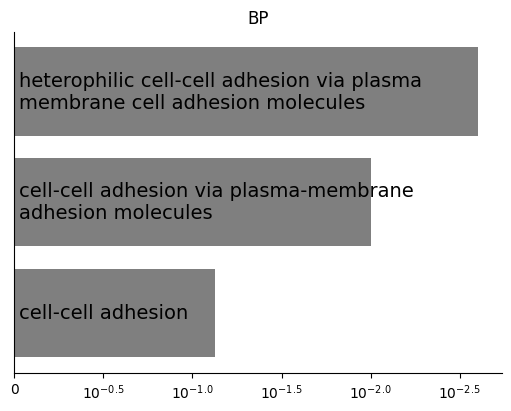

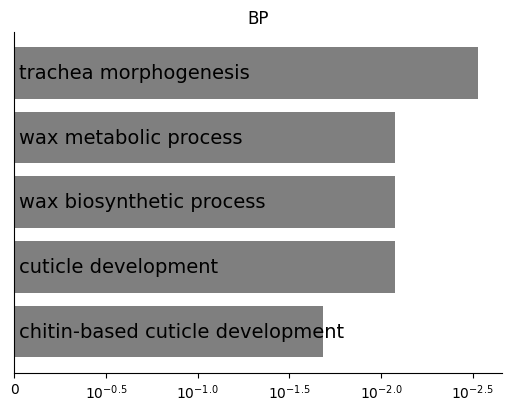

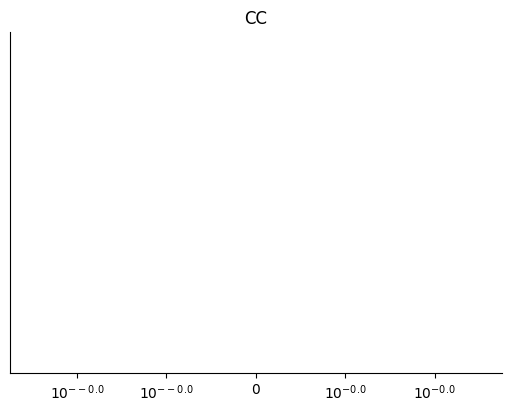

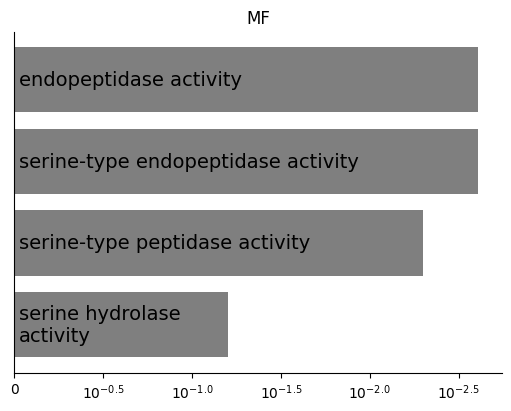

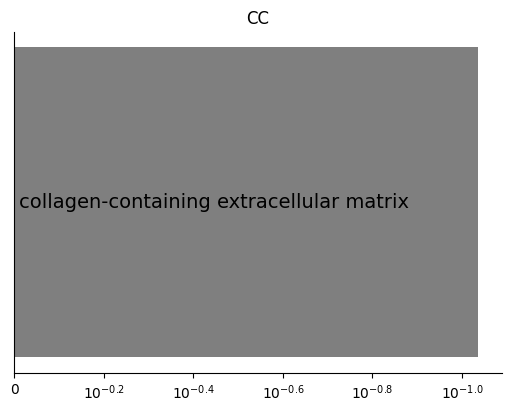

In [46]:
#meth_pop = mt_muscle_meth['name'].unique().to_numpy()
#acet_pop = mt_muscle_acet['name'].unique().to_numpy()
#pop = rna_acme_corr['var_name'].unique().to_numpy()
for c in ['Midgut', 'Muscle', 'Ventral Nerve Cord', 'Epidermis', 'Fat Body']:
    df = acetlate.filter(pl.col('group')==c)
    pop = df['name'].unique().to_numpy()
    upr = df.filter(pl.col('pval')<0.1).filter(pl.col('score')<-0.1).top_k(200,by='pval',reverse=True)['name'].to_numpy()

    res = scit.tl.goea(
        obodag,
        ns2assoc,
        scit.tl.symbol2id(ref, pop),
        scit.tl.symbol2id(ref, upr),
        #scit.tl.symbol2id(ref, rna_acme_corr.filter(pl.col('res') < 0.3).filter(pl.col('res_meth') > 0.2)['var_name'].to_numpy()),
        # mt_muscle_acet.filter((pl.col('pval')<0.01) & (pl.col('score') < -0.2))['name'].to_numpy()),
        propagate_counts=True,
        alpha=0.1
    )

    scit.set_defaults(figsize=(5,4))
    fs=scit.pl.goea(res, color='tab:gray', mode='enriched_only', n_top=5, plot_type='smart', text_size=14, wrap_width=50,show=False)
    v = '' if not ANATOMIC_TERM else '_anatomic'
    [fs[i].savefig(f'private/newest/goterm/acetlate_{c}_marker_{i}{v}.pdf') for i in range(len(fs))]
    pl.DataFrame(res.df).write_csv(f'private/newest/goterm/acetlate_{c}_marker{v}.csv')